**¿Qué es un árbol de decisión?**

Es un modelo de aprendizaje supervisado (sirve tanto para clasificación como para regresión) que toma decisiones secuenciales basadas en reglas del tipo:

“Si esta variable es mayor que X, voy por aquí.
Si no, voy por allá.”

Visualmente se parece a un árbol invertido:
* Nodo raíz → primera pregunta
* Nodos internos → más preguntas
* Hojas → predicción final

Por ejemplo, en clasificación de clientes:
* ¿Edad > 35?
* ¿Ingreso > 800.000?
* ¿Tiene deuda?

**¿Cómo aprende?**

El modelo construye el árbol buscando las divisiones que mejor separan los datos.
En clasificación usa métricas como:

* Gini
* Entropía

En regresión busca minimizar el error cuadrático (MSE).

Básicamente: prueba muchas preguntas posibles y elige la que reduce más la impureza.

**¿Por qué son tan usados?**

1. Son fáciles de interpretar.
2. No requieren escalamiento de variables.
3. Manejan bien variables numéricas y categóricas.
4. Capturan relaciones no lineales.

**Pero tienen su lado complejo**

Un árbol solo puede:
* Sobreajustarse fácilmente.
* Volverse inestable (pequeños cambios en datos → árbol muy distinto).
* Generalizar peor que modelos ensamblados.

Por eso muchas veces se usan como base para modelos más robustos:
* Random Forest
* Gradient Boosting
* XGBoost

**Cómo se implementa en Python**

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Dataset ficticio
data = pd.DataFrame({
    "antiguedad": [2, 12, 4, 24, 3, 18, 5, 30],
    "reclamos": [5, 1, 4, 0, 2, 1, 6, 0],
    "churn": [1, 0, 1, 0, 0, 0, 1, 0]
})

X = data[["antiguedad", "reclamos"]]
y = data["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

modelo = DecisionTreeClassifier(max_depth=2, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



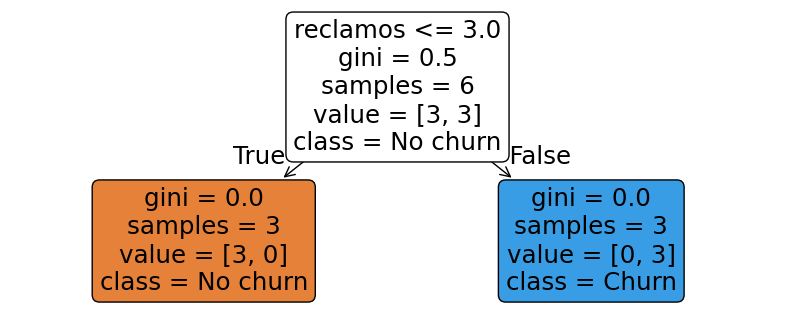

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 4))
plot_tree(
    modelo,
    feature_names=["antiguedad", "reclamos"],
    class_names=["No churn", "Churn"],
    filled=True,
    rounded=True,
    impurity=True
)
plt.show()

# **Ejemplo de arbol con Dataset Iris**

Cargar y dividir datos

In [7]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [8]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = tree.predict(X_test)

print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte:\n", classification_report(y_test, y_pred, digits=3))

Matriz de confusión:
 [[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]

Reporte:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000        15
           1      1.000     0.800     0.889        15
           2      0.833     1.000     0.909        15

    accuracy                          0.933        45
   macro avg      0.944     0.933     0.933        45
weighted avg      0.944     0.933     0.933        45



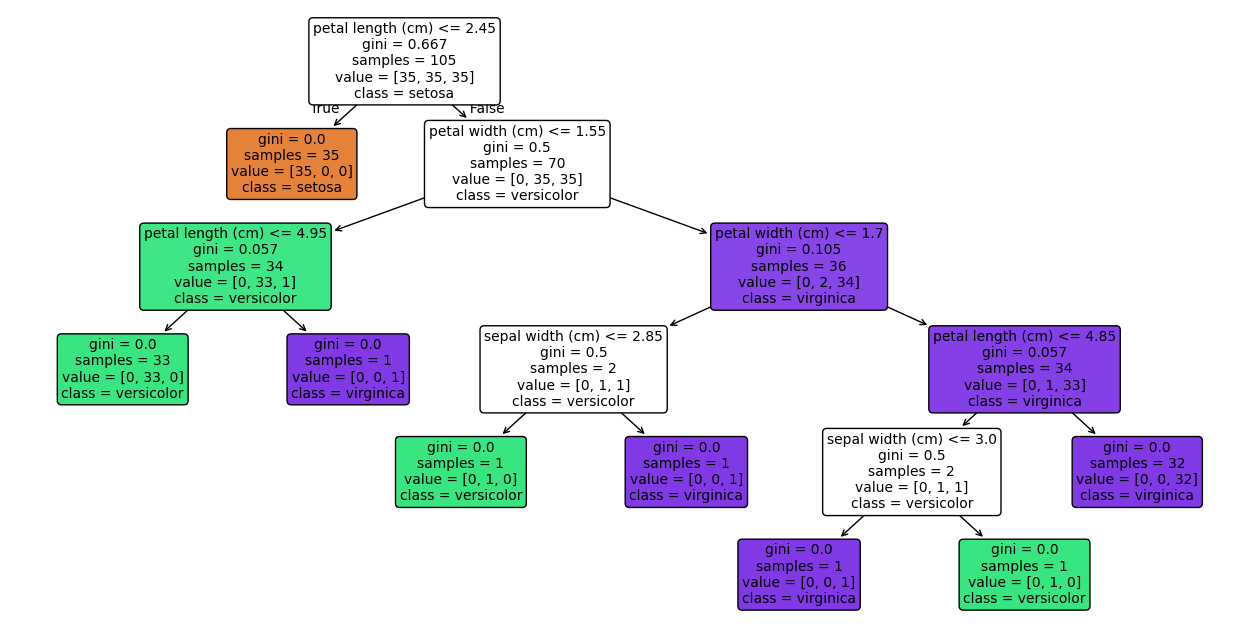

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16,8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

# **Ejemplo de árbol con dataset load_breast_cancer**

In [11]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target  # 0=maligno, 1=benigno

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Árbol "sin control" (a propósito)
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

y_pred = tree_full.predict(X_test)

print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte:\n", classification_report(y_test, y_pred, digits=3))

Matriz de confusión:
 [[49  4]
 [ 7 83]]

Reporte:
               precision    recall  f1-score   support

           0      0.875     0.925     0.899        53
           1      0.954     0.922     0.938        90

    accuracy                          0.923       143
   macro avg      0.915     0.923     0.918       143
weighted avg      0.925     0.923     0.923       143



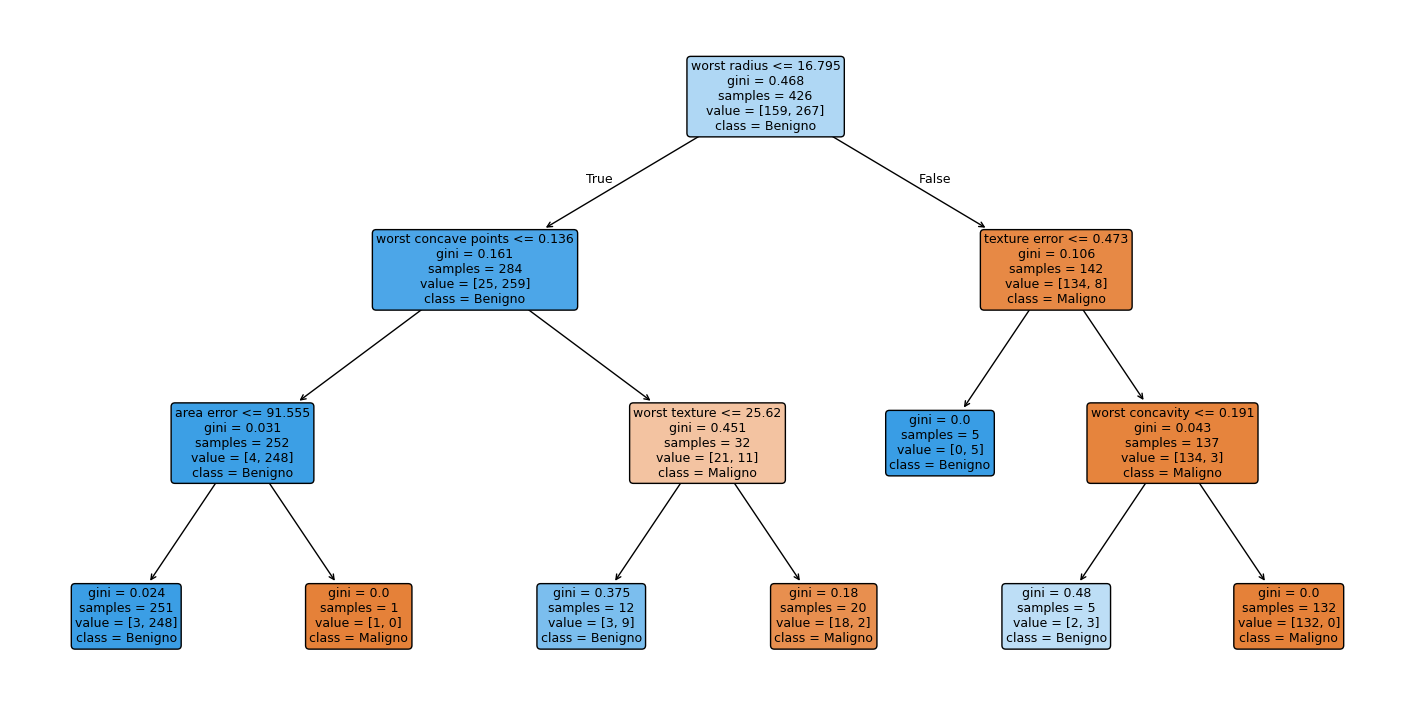

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_small = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_small.fit(X_train, y_train)

plt.figure(figsize=(18, 9))
plot_tree(
    tree_small,
    feature_names=X.columns,
    class_names=["Maligno", "Benigno"],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=9
)
plt.show()

In [13]:
from sklearn.metrics import accuracy_score

def eval_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test  = accuracy_score(y_test, model.predict(X_test))
    return acc_train, acc_test

models = {
    "Sin control": DecisionTreeClassifier(random_state=42),
    "Max depth=3": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Min leaf=10": DecisionTreeClassifier(min_samples_leaf=10, random_state=42),
    "Depth=4 + leaf=10": DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42),
}

for name, m in models.items():
    tr, te = eval_model(m, X_train, y_train, X_test, y_test)
    print(f"{name:20s} | Acc Train: {tr:.3f} | Acc Test: {te:.3f}")

Sin control          | Acc Train: 1.000 | Acc Test: 0.923
Max depth=3          | Acc Train: 0.977 | Acc Test: 0.944
Min leaf=10          | Acc Train: 0.962 | Acc Test: 0.951
Depth=4 + leaf=10    | Acc Train: 0.962 | Acc Test: 0.951
